In [1]:
import numpy as np
import matplotlib.pyplot as plt
from magnonics import *
import sympy as sp
from sympy import latex, Matrix, simplify, symbols
from IPython.display import Math, display

In [2]:
hexagonal, _, _ = Initialize.from_csv('configs/hexagonal.csv')

In [3]:
hexagonal.lat.num_rcpr_vects.T @ np.array(([1/3], [-1/3], [0]))

array([[ 1.20919958],
       [-2.0943951 ],
       [ 0.        ]])

In [4]:
hexagonal.assume_real_parameters()

{'a': a, 'S1': S1, 'J': J, 'J2': J2, 'A': A, 'Dz': Dz, 'g': g, 'B': B}

In [5]:
Hmat = hexagonal.HP_trafo(symbolic=True, simplify=True) # FIXME fails for symbolic = False (numeric calculation), chempot way to high

In [6]:
block1 = Hmat[0:2, 0:2]
block2 = Hmat[2:4, 2:4]

In [7]:
sym_map = {s.name: s for s in block1.free_symbols}
print(block1.free_symbols)

{J, Dz, S1, A, B_z, g, a, J2, k_y, k_x}


In [8]:
new = block1.subs({
    sym_map['k_x']: 2 * sp.pi / (3*sp.sqrt(3)), 
    sym_map['k_y']: - 2 * sp.pi / 3,
    sym_map['A']: 0,
    sym_map['B_z']: 0,
    sym_map['a']: 1,
    sym_map['g']: 1,
    sym_map['S1']: 1,
    sym_map['J']: -1,
    sym_map['J2']: -0.1,
    sym_map['Dz']: 0.1,
})

In [9]:
display(Math(r'\Large ' + latex(
    sp.nsimplify(new)
    )))

<IPython.core.display.Math object>

In [22]:
# 1. Define your parameters as symbols
J, K, D = sp.symbols('J K D', real = True)

# 2. Set up your 3x3 matrix
# I'll put the parameters on the diagonal for clarity, 
# but you can place them anywhere.
M = sp.Matrix([
    [-3*J - 9*K - 3*sp.sqrt(3)*D, 0],
    [0, -3*J - 9*K + 3*sp.sqrt(3)*D]
])

# 3. Calculate eigenvalues
# This returns a dictionary: {eigenvalue: multiplicity}
e_vals = M.eigenvals()

# Print them nicely
display(Math(r'\Large ' + latex(
    e_vals
    )))

<IPython.core.display.Math object>

Automatically finding sufficient chemical potential...
Using 1e-10 as chemical potential.
Updated parameters and now using 1e-10 as chemical potential.


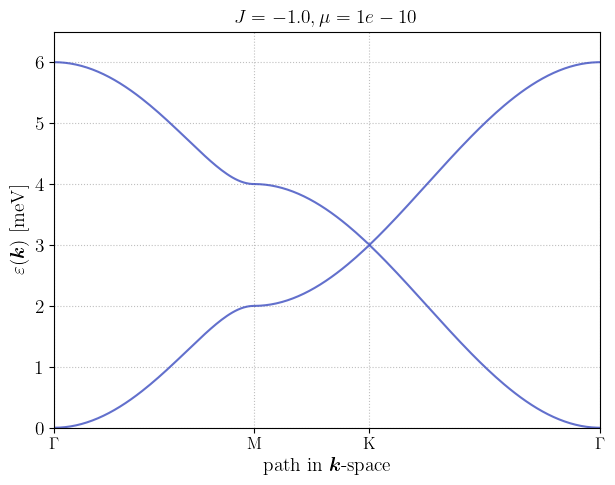

In [16]:
hexagonal.update_parameters({'J2': 0, 'Dz': 0})

bz = Hexagonal(hexagonal, 'hexagonal_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

Updated parameters and now using 1e-08 as chemical potential.


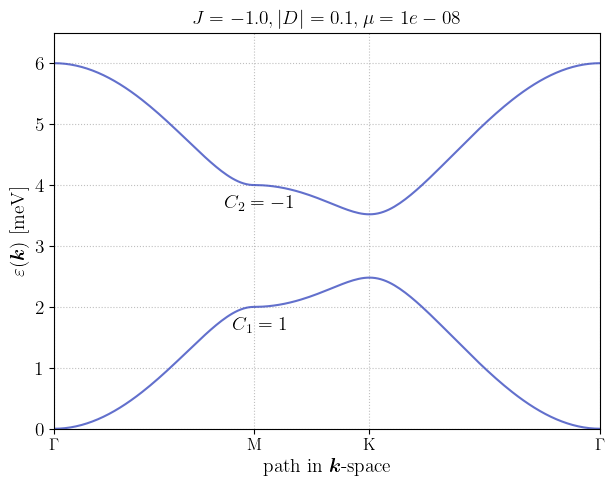

In [17]:
hexagonal.update_parameters({'J2': 0, 'Dz': 0.1}, 1e-8)

bz = Hexagonal(hexagonal, 'hexagonal_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

Updated parameters and now using 1e-08 as chemical potential.


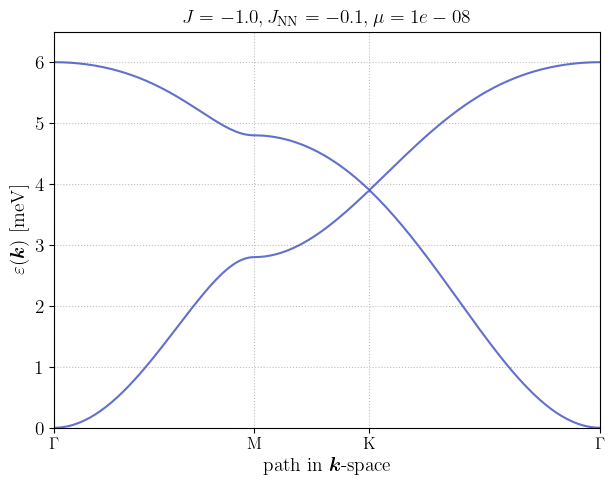

In [18]:
hexagonal.update_parameters({'J2': -0.1, 'Dz': 0}, 1e-8)

bz = Hexagonal(hexagonal, 'hexagonal_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

Updated parameters and now using 1e-08 as chemical potential.


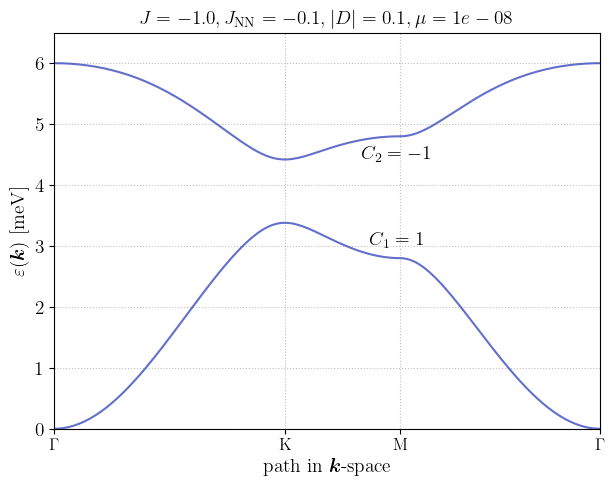

In [19]:
hexagonal.update_parameters({'J2': -0.1, 'Dz': 0.1, 'S1': 1}, 1e-8)

bz = Hexagonal(hexagonal, 'hexagonal_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.k, hsp.m, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

In [413]:
kagome, _, _ = Initialize.from_csv('configs/kagome_test.csv')

In [346]:
kagome.lat.num_rcpr_vects.T @ np.array(([1/3], [-1/3], [0]))

array([[4.1887902],
       [0.       ],
       [0.       ]])

In [347]:
kagome.assume_real_parameters()

{'a': a,
 'S1': S1,
 'J': J,
 'J2': J2,
 'A': A,
 'Dz': Dz,
 'g': g,
 'B': B,
 'chempot': chempot}

In [414]:
Hmat2 = kagome.HP_trafo(symbolic=True)

In [349]:
bl1 = Hmat2[0:3, 0:3]
bl2 = Hmat2[3:6, 3:6]

In [377]:
display(Math(r'\Large ' + latex(
    sp.nsimplify(bl1)
    )))

<IPython.core.display.Math object>

In [360]:
sym_map = {s.name: s for s in bl1.free_symbols}
print(bl1.free_symbols)

{A, J2, S1, g, B_z, a, k_x, J, Dz, k_y}


In [402]:
new2 = bl1.subs({
    sym_map['k_x']: 0, 
    sym_map['k_y']: 0,
    sym_map['A']: 0,
    sym_map['B_z']: 0,
    sym_map['a']: 1,
    sym_map['g']: 1
})

In [407]:
display(Math(r'\Large ' + latex(
    sp.nsimplify(new2)
    )))

<IPython.core.display.Math object>

In [409]:
# 1. Define your parameters as symbols
J, K, D = sp.symbols('J K D', real = True)

# 2. Set up your 3x3 matrix
# I'll put the parameters on the diagonal for clarity, 
# but you can place them anywhere.
M = sp.Matrix([
    [-4*J - 2*K, 2*J + K - 2*sp.I*D, 2*J + K + 2*sp.I*D],
    [2*J + K + 2*sp.I*D, -4*J - 2*K, 2*J + K - 2*sp.I*D],
    [2*J + K - 2*sp.I*D, 2*J + K + 2*sp.I*D, -4*J - 2*K]
])

# 3. Calculate eigenvalues
# This returns a dictionary: {eigenvalue: multiplicity}
e_vals = M.eigenvals()

# Print them nicely
display(Math(r'\Large ' + latex(
    e_vals
    )))

<IPython.core.display.Math object>

Updated parameters and now using 1e-08 as chemical potential.


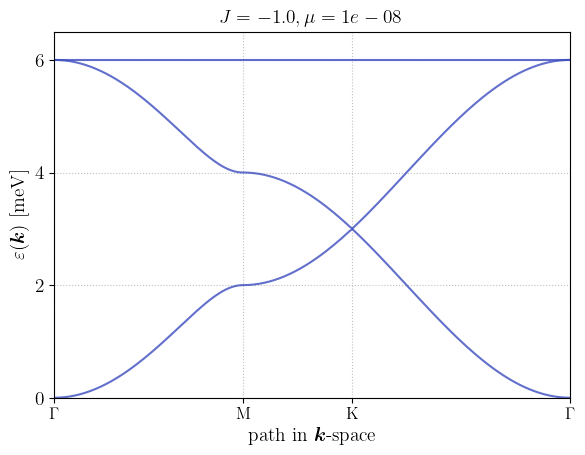

In [420]:
kagome.update_parameters({'J': -1, 'J2': 0, 'Dz': 0})

bz = Hexagonal(kagome, 'kagome_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

Updated parameters and now using 1e-08 as chemical potential.


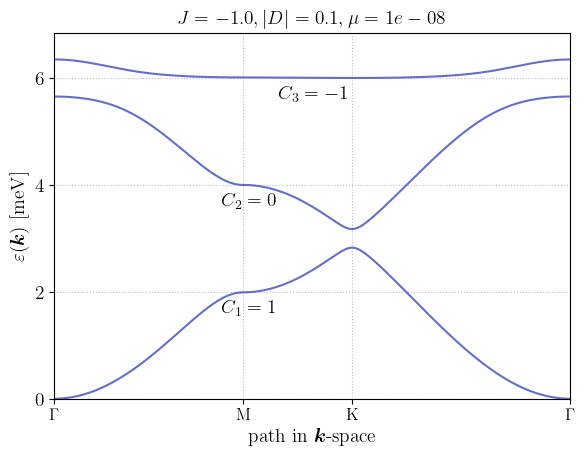

In [433]:
kagome.update_parameters({'J': -1, 'J2': 0, 'Dz': -0.1}, 1e-8)

bz = Hexagonal(kagome, 'kagome_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

Updated parameters and now using 1e-08 as chemical potential.


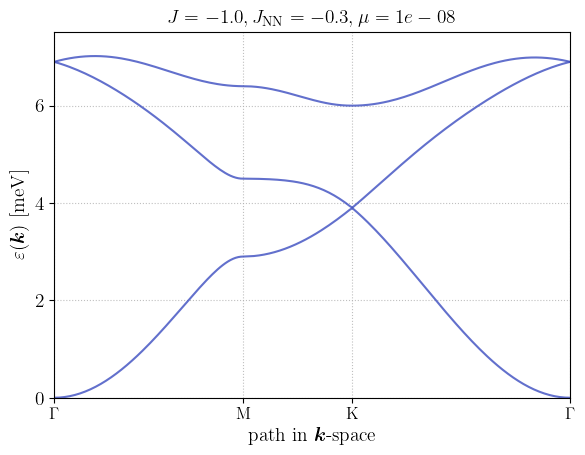

In [ ]:
kagome.update_parameters({'J': -1, 'J2': -0.3, 'Dz': 0}, 1e-8) 

bz = Hexagonal(kagome, 'kagome_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

Updated parameters and now using 1e-08 as chemical potential.


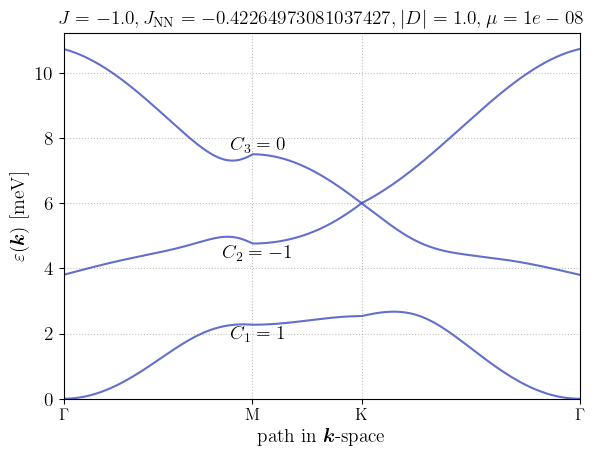

In [441]:
kagome.update_parameters({'J': -1, 'J2': -(3-np.sqrt(3))/3, 'Dz': -1}, 1e-8) # (3-np.sqrt(3))/6

bz = Hexagonal(kagome, 'kagome_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

Updated parameters and now using 1e-08 as chemical potential.


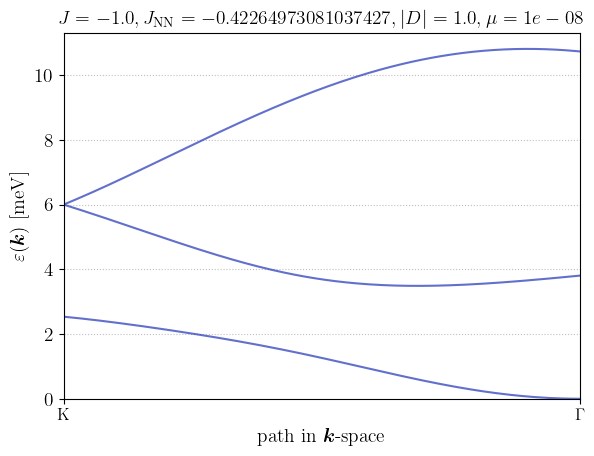

In [442]:
kagome.update_parameters({'J': -1, 'J2': -(3-np.sqrt(3))/3, 'Dz': 1}, 1e-8) # (3-np.sqrt(3))/6

bz = Hexagonal(kagome, 'kagome_test')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)